In [1]:
%load_ext autoreload
%autoreload 2

# ignore warnings for readability
import warnings
warnings.filterwarnings('ignore')

import os
from os.path import join
from collections import defaultdict
import numpy as np
import pandas as pd
import tqdm
from sklearn.linear_model import LinearRegression

import logging
logging.getLogger('fontTools.subset').setLevel(logging.WARNING)

# matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.style.use('euclid_stylesheet_v2.mplstyle')
mpl.rcParams['figure.dpi'] = 300

In [2]:
mdir = './saved_models'


def r2logm(r):
    # see preprocessing.ipynb for this measurement
    coef = 0.36752
    intercept = -5.30640
    return (np.log10(r)-intercept)/coef

In [3]:
datanames = ['wC50', 'wC100', 'dC50', 'dC100']
runnames = ['base', 'gals_nle', 'summ_nle', 'gnn_npe']
modelnames = ['msig', 'pamico', 'mamp', 'gals_nle', 'summ_nle', 'gnn_npe']
Nfolds = 10
folds = np.arange(Nfolds)

datatitles = dict(
    wC50='Wide $50\%$',
    wC100='Wide $100\%$',
    dC50='Deep $50\%$',
    dC100='Deep $100\%$'
)
modeltitles = dict(
    msig='$M$--$\sigma$',
    pamico=r'$M$--$\lambda_{\rm spec}$',
    mamp='MAMPOSSt',
    gals_nle='Galaxy-Net',
    summ_nle='Summary-Net',
    gnn_npe='Graph-Net',
    true='True',
    prior='Prior',
    dummy='Dummy'
)

In [4]:
from scipy.stats import skewnorm
from scipy.optimize import minimize


def fit_skewed_normal(p16, p50, p84):
    target_percentiles = [0.16, 0.50, 0.84]
    observed_values = [p16, p50, p84]

    def objective(params):
        loc, scale, alpha = params
        if scale <= 0:
            return np.inf
        skewed_gaussian = skewnorm(alpha, loc=loc, scale=scale)
        calculated_values = skewed_gaussian.ppf(target_percentiles)
        return np.sum((calculated_values - observed_values) ** 2)

    initial_guess = [p50, (p84 - p16) / 2, 0.5]
    result = minimize(objective, initial_guess)
    loc, scale, alpha = result.x
    return skewnorm(alpha, loc=loc, scale=scale)

In [5]:
# load train/test
header = 'APR24'
datadir = './data/processed'

theta, fold, ids, richs, zclus, Ngal = {}, {}, {}, {}, {}, {}
for d in datanames:
    dirpath = join(datadir, f'{header}{d}')
    print('Loading:', dirpath)
    theta[d] = np.load(join(dirpath, 'theta_batch.npy'))
    fold[d] = np.load(join(dirpath, 'folds_batch.npy'))
    ids[d] = np.load(join(dirpath, 'ids_batch.npy'))
    metas = np.load(join(dirpath, 'metas_batch.npy'))
    zclus[d] = metas[:, 3]  # cluster photometric redshift
    richs[d] = metas[:, 1]  # sum of AMICO photometry
    Ngal[d] = np.load(join(dirpath, 'x_sum.npy'))[:, -1]

Ndata = {d: len(theta[d]) for d in datanames}
print(Ndata)

Loading: ./data/processed/APR24wC50
Loading: ./data/processed/APR24wC100
Loading: ./data/processed/APR24dC50
Loading: ./data/processed/APR24dC100
{'wC50': 840, 'wC100': 907, 'dC50': 1998, 'dC100': 2014}


In [6]:
Nsamp = 100
preds = defaultdict(dict)
for d in datanames:
    for r in runnames:
        # setup
        if r == 'base':
            preds[d]['msig'] = np.ones((Ndata[d], 2))*np.nan
            preds[d]['pamico'] = np.ones((Ndata[d], 2))*np.nan
        else:
            preds[d][r] = np.full((Ndata[d], Nsamp, 1), np.nan)

        # load
        for f in folds:
            if r == 'gnn_npe':
                dirname = f'oct02_{r}_{d}_f{f}'
            else:
                dirname = f'apr24_{r}_{d}_f{f}'
            if r == 'base':
                # Msig
                samplefile = join(mdir, dirname, 'msig.npz')
                if not os.path.exists(samplefile):
                    print(f'Skipping {dirname}')
                    continue
                s = np.load(samplefile)
                place_ids = np.searchsorted(ids[d], s['ids'])
                np.put(preds[d]['msig'][:, 0], place_ids, s['pred'])
                np.put(preds[d]['msig'][:, 1], place_ids, s['std'])

                # Pamico
                samplefile = join(mdir, dirname, 'Pamico.npz')
                if not os.path.exists(samplefile):
                    print(f'Skipping {dirname}')
                    continue
                s = np.load(samplefile)
                place_ids = np.searchsorted(ids[d], s['ids'])
                np.put(preds[d]['pamico'][:, 0], place_ids, s['pred'])
                np.put(preds[d]['pamico'][:, 1], place_ids, s['std'])

            else:
                # ML models
                samplefile = join(mdir, dirname, 'posterior_samples.npy')
                if not os.path.exists(samplefile):
                    print(f'Skipping {dirname}')
                    continue
                s = np.load(samplefile)
                s = np.swapaxes(s, 0, 1)
                s = s[:, :Nsamp]  # subsample if necessary
                preds[d][r][fold[d] == f] = s

In [7]:
# load mamposst

mamnames = {
    'wC50': 'wide50', 'wC100': 'wide100', 'dC50': 'deep50', 'dC100': 'deep100'
}
modeldir = './saved_models/mamposst_newprior_dec1824/'

for k, v in mamnames.items():
    isamp = pd.read_csv(join(modeldir, f'result_MockFS_NewAMICO_{v}.dat'),
                        delimiter=' ', skipinitialspace=True)
    isamp['id'] = isamp['#ClusterID'].astype(int)
    # convert r200 to logm
    for c in isamp.columns:
        if 'r200' not in c:
            continue
        isamp['logm'+c[4:]] = r2logm(isamp[c])

    # put in preds
    preds[k]['mamp'] = np.ones((Ndata[k], 5))*np.nan
    place_ids = np.searchsorted(ids[k], isamp['id'].values)
    mask = place_ids < Ndata[k]
    _s = isamp[['logmlow(68)', 'logmup(68)', 'logmlow(95)',
                'logmup(95)', 'logmMAM']].values
    preds[k]['mamp'][place_ids[mask]] = _s[mask]

In [8]:
# calculate percentiles from predictions
q = 100*np.array([0.16, 0.84, 0.5, 0.025, 0.975])
percs = defaultdict(dict)
for d in datanames:
    for m in modelnames:
        if m == 'msig' or m == 'pamico':
            t_ = preds[d][m]
            percs[d][m] = np.stack(
                [t_[:, 0]-t_[:, 1], t_[:, 0]+t_[:, 1], t_[:, 0],
                    t_[:, 0]-2*t_[:, 1], t_[:, 0]+2*t_[:, 1]],
                axis=1).T
        elif m == 'mamp':
            if m not in preds[d]:
                continue
            t_ = preds[d][m]
            percs[d][m] = np.stack(
                [t_[:, 0], t_[:, 1], t_[:, 4], t_[:, 2], t_[:, 3]],
                axis=1).T
        else:
            t_ = preds[d][m]
            percs[d][m] = np.percentile(t_, q, axis=1)[..., 0]
# percs is of shape (5, Ndata)
# dim 0 is of order [16, 84, 50, 2.5, 97.5]

In [9]:
# Compute quality control
def quality_control(percs):
    # checks if we have a reasonable median prediction
    # checks if we're not missing a prediction (not nan)
    med = percs[2]
    mask = (med > 12) & (med < 16)

    err = (percs[1] - percs[0])/2
    mask &= err < 1
    return mask


qc = defaultdict(dict)
for d in datanames:
    for m in modelnames:
        qc[d][m] = quality_control(percs[d][m])

In [10]:
# Remove Ngal < 3
for d in datanames:
    mask = Ngal[d] >= 3

    theta[d] = theta[d][mask]
    fold[d] = fold[d][mask]
    ids[d] = ids[d][mask]
    richs[d] = richs[d][mask]
    zclus[d] = zclus[d][mask]
    Ngal[d] = Ngal[d][mask]
    Ndata[d] = len(theta[d])

    for m in modelnames:
        if m not in percs[d]:
            continue
        preds[d][m] = preds[d][m][mask]
        percs[d][m] = percs[d][m][:, mask]
        qc[d][m] = qc[d][m][mask]

## MCMC -- v6: joint mass-posterior calibration

Forward mass-richness relation (`8_newappendix.tex`) **plus** a calibration of a
biased mass posterior using a small subset of clusters with known true masses.

Each posterior is summarized by its mean $\mu_i$ and width $\sigma_i$. The true
mass is modeled as an affine map plus scatter:
$$m_{\rm true}\mid(\mu,\sigma)\sim\mathcal N\!\big(\alpha+\beta(\mu-\mu_{\rm ref}),\;\sigma_{\rm cal}^2+\kappa^2\sigma^2\big).$$
Calibration params: $\alpha$ (offset), $\beta$ (scale, ideal 1), $\sigma_{\rm cal}$
(floor), $\kappa$ (width inflation, ideal 1). $\mu_{\rm ref}=\langle\mu\rangle_{\rm cal}$.

**Two likelihood terms in one MCMC** (8 params total):
1. **calibration** on the true-mass subset -> fixes $\alpha,\beta,\sigma_{\rm cal},\kappa$;
2. **main** sample, calibrated posterior marginalized analytically:
   $\ell_i\sim\mathcal N(\pi_0+F_m(\mu_{{\rm cal},i}-m_0)+G_z\zeta_i,\ \sigma_\lambda^2+F_m^2 s_i^2)$,
   $s_i^2=\sigma_{\rm cal}^2+\kappa^2\sigma_i^2$.

The M-lambda relation is fit **from the main sample only**; the calibration
subset informs **only** the mass-calibration map ($\mu\to m_{\rm true}$, a
property of the mass estimator). This does **not** assume the cal and main
samples share the same relation. Identifiability still holds: the main sample
fixes $S=F_m\beta$ and $I=\pi_0+F_m(\alpha-m_0)$, and term 1 anchors $\alpha,\beta$
on an absolute scale -> $F_m,\pi_0$ resolve, with calibration uncertainty
propagating into $F_m$. (A previous "anchor" term that put cal clusters into the
relation with their true masses was removed, since it would assume a shared
relation.) `inject_bias` makes a known biased posterior to validate recovery.

In [11]:
# LinearRegression to estimate the FORWARD relation: log10(lambda) | m, z
# (new appendix parametrization, see 8_newappendix.tex)
d = 'dC100'
rs = richs[d]
zs = zclus[d]
mtrue = theta[d][:, 0]

# find pivots: mass pivot m0 and redshift pivot z0
m0_piv, z0 = 14.0, 1.0

# regress log10(lambda) on (m - m0) and log10((1+z)/(1+z0))
dm = mtrue - m0_piv
dz = np.log10((1+zs)/(1+z0))
X = np.stack([dm, dz], axis=1)
ylam = np.log10(rs)
reg = LinearRegression().fit(X, ylam)
y_pred = reg.predict(X)
residual_std = np.std(ylam - y_pred)
print(f'pi0 (intercept): {reg.intercept_:.3f}')
print(f'F_m  (mass slope): {reg.coef_[0]:.3f}')
print(f'G_z  (redshift slope): {reg.coef_[1]:.3f}')
print(f'sigma_lambda (residual std): {residual_std:.3f}')

pi0 (intercept): 1.409
F_m  (mass slope): 0.334
G_z  (redshift slope): 2.075
sigma_lambda (residual std): 0.134


In [ ]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import corner

# v6: joint mass-posterior calibration + forward mass-richness relation.
# Calibration model:  m_true | (mu, sig) ~ N(alpha + beta(mu - mu_ref),
#                                             sigcal^2 + kappa^2 sig^2).
# The main-sample mass is marginalized analytically (Gaussian calibrated
# posterior x Gaussian, linear-in-mass richness mean), giving a Gaussian in
# log10(lambda) with variance sigl^2 + Fm^2 (sigcal^2 + kappa^2 sig^2).
#
# Two terms only:
#   (1) calibration on the true-mass subset -> fixes alpha, beta, sigcal, kappa;
#   (2) the M-lambda relation, fit FROM THE MAIN SAMPLE ONLY.
# The calibration subset informs only the mass-calibration map (a property of
# the mass estimator); it does NOT assume the cal and main samples share the
# same M-lambda relation. (alpha,beta are anchored by term 1, not by any
# relation term, so the F_m<->beta / pi0<->alpha degeneracy is still broken.)


def relation_mean(m, dz, m0, pi0, Fm, Gz):
    # <log10 lambda | m, z>; dz = log10((1+z)/(1+z0))
    return pi0 + Fm*(m - m0) + Gz*dz


def model_calib(mu_main, sig_main, dz_main, loglam_main,
                mu_cal, sig_cal, mtrue_cal, m0, mu_ref):
    # relation params (fit from the main sample only)
    pi0 = numpyro.sample("pi0", dist.Uniform(-2, 5))
    Fm = numpyro.sample("Fm", dist.Uniform(-10, 10))
    Gz = numpyro.sample("Gz", dist.Uniform(-10, 10))
    sigl = numpyro.sample("sigl", dist.LogUniform(1e-2, 2.0))
    # calibration params
    alpha = numpyro.sample("alpha", dist.Uniform(11.0, 16.0))
    beta = numpyro.sample("beta", dist.Uniform(0.0, 3.0))
    sigcal = numpyro.sample("sigcal", dist.LogUniform(1e-3, 1.0))
    kappa = numpyro.sample("kappa", dist.LogUniform(0.1, 5.0))

    # (1) calibration likelihood on the true-mass subset (fixes alpha, beta)
    cal_mean = alpha + beta*(mu_cal - mu_ref)
    cal_sd = jnp.sqrt(sigcal**2 + (kappa*sig_cal)**2)
    numpyro.factor("cal", dist.Normal(
        cal_mean, cal_sd).log_prob(mtrue_cal).sum())

    # (2) main sample: analytic marginal over the calibrated Gaussian posterior
    mu_cal_main = alpha + beta*(mu_main - mu_ref)
    s2 = sigcal**2 + (kappa*sig_main)**2
    mean_lam = relation_mean(mu_cal_main, dz_main, m0, pi0, Fm, Gz)
    sd_lam = jnp.sqrt(sigl**2 + (Fm**2)*s2)
    numpyro.factor("main",
                   dist.Normal(mean_lam, sd_lam).log_prob(loglam_main).sum())


def model_true(mtrue, dz, loglam, m0):
    # reference: fit the relation directly from true masses (no calibration)
    pi0 = numpyro.sample("pi0", dist.Uniform(-2, 5))
    Fm = numpyro.sample("Fm", dist.Uniform(-10, 10))
    Gz = numpyro.sample("Gz", dist.Uniform(-10, 10))
    sigl = numpyro.sample("sigl", dist.LogUniform(1e-2, 2.0))
    mean_lam = relation_mean(mtrue, dz, m0, pi0, Fm, Gz)
    numpyro.factor("rel", dist.Normal(mean_lam, sigl).log_prob(loglam).sum())


def run_calib(*args, warmup=500, samples=1000, chains=4):
    kernel = NUTS(model_calib, dense_mass=True)
    mcmc = MCMC(kernel, num_warmup=warmup, num_samples=samples,
                num_chains=chains, chain_method='vectorized')
    mcmc.run(jax.random.PRNGKey(0), *args)
    return mcmc.get_samples()


def run_true(mtrue, dz, loglam, m0, warmup=500, samples=1000, chains=4):
    kernel = NUTS(model_true, dense_mass=True)
    mcmc = MCMC(kernel, num_warmup=warmup, num_samples=samples,
                num_chains=chains, chain_method='vectorized')
    mcmc.run(jax.random.PRNGKey(1), jnp.asarray(mtrue), jnp.asarray(dz),
             jnp.asarray(loglam), m0)
    return mcmc.get_samples()

In [20]:
# ============================================================
# Likelihood playground -- set the knobs here
# ============================================================
d = 'dC100'        # dataset: wC50, wC100, dC50, dC100
m = 'msig'        # mass model: msig, pamico, mamp, gals_nle, summ_nle,
#             gnn_npe, true, dummy
m0_piv, z0 = 13.78, 0.82     # mass and redshift pivots
m0, sig0 = 13.78, 0.348      # assumed mass prior p(m) ~ N(m0, sig0^2)
# ============================================================

rs = richs[d]
zs = zclus[d]
ytrue = theta[d][:, 0]

# build mass posterior samples `samps` of shape (Nclu, Nsamp)
if m in ['msig', 'pamico']:
    mu, sig = preds[d][m].T
    samps = mu[:, None] + sig[:, None]*np.random.randn(len(mu), Nsamp)
elif m == 'mamp':
    ps = preds[d][m]
    p16, p84, p50 = ps[:, 0], ps[:, 1], ps[:, 4]
    samps = np.array([
        fit_skewed_normal(p16[i], p50[i], p84[i]).rvs(Nsamp)
        if not np.isnan(p16[i]) else np.full(Nsamp, np.nan)
        for i in tqdm.tqdm(range(len(p16)))
    ])
elif m == 'dummy':
    # synthetic posteriors for testing the likelihood: noisy + prior-shrunk
    mu_p, sig_p = 13.78, 0.35   # mock inference prior p(m)
    sigma_n = 0.3               # injected noise (dex)
    post_var = 1.0/(1.0/sigma_n**2 + 1.0/sig_p**2)
    x = ytrue + sigma_n*np.random.randn(len(ytrue))
    post_mean = post_var*(x/sigma_n**2 + mu_p/sig_p**2)
    samps = (post_mean[:, None]
             + np.sqrt(post_var)*np.random.randn(len(ytrue), Nsamp))
    qc[d]['dummy'] = qc[d]['gnn_npe']
elif m == 'prior':
    # samps = np.random.randn(len(ytrue), Nsamp) * sig0 + m0
    samps = np.random.randn(len(ytrue), Nsamp) * sig0 + \
        reg_mz.predict(zs.reshape(-1, 1))[:, None]
    qc[d]['prior'] = qc[d]['gnn_npe']
elif m == 'true':
    samps = ytrue[:, None]
    qc[d]['true'] = qc[d]['gnn_npe']
else:
    samps = preds[d][m][..., 0]

# quality control + observed log10 richness (the "data" in the likelihood)
mask = qc[d][m]
# mask &= (0.75 < zs) & (zs < 0.8)
rs, zs, samps, ytrue = rs[mask], zs[mask], samps[mask], ytrue[mask]
loglambs = np.log10(rs)

print('samps shape:', samps.shape)
print('true mass mean/std:', ytrue.mean(), ytrue.std())

samps shape: (2011, 100)
true mass mean/std: 13.776279314692555 0.3478197473087921


In [21]:
# ============================================================
# Calibration setup: split clusters into a true-mass subset + main sample.
# Summarize each posterior by (mu_i, sig_i). Optionally inject a KNOWN affine
# bias (from the true masses) to validate that calibration recovers the
# true-mass relation. Set inject_bias=False to calibrate the real `samps`.
# ============================================================
cal_frac = 0.2          # fraction of clusters with known true mass
inject_bias = False      # synthetic biased posterior for validation
rng = np.random.default_rng(0)
Nclu = len(ytrue)

if inject_bias:
    # biased posterior: shrunk toward m0 (beta<1), offset, heteroscedastic width
    shrink, offset = 0.6, 0.12
    sig_i = rng.uniform(0.15, 0.35, Nclu)             # reported widths (vary)
    mu_i = (m0 + shrink*(ytrue - m0) + offset
            + 0.5*sig_i*rng.standard_normal(Nclu))
else:
    mu_i = samps.mean(axis=1)
    sig_i = samps.std(axis=1)

dz = np.log10((1 + zs) / (1 + z0))
is_cal = rng.random(Nclu) < cal_frac
mu_ref = float(mu_i[is_cal].mean())

# main sample (true mass treated as unknown)
mu_main, sig_main = mu_i[~is_cal], sig_i[~is_cal]
dz_main, loglam_main = dz[~is_cal], loglambs[~is_cal]
# calibration subset (true mass known)
mu_cal, sig_cal = mu_i[is_cal], sig_i[is_cal]
dz_cal, loglam_cal, mtrue_cal = dz[is_cal], loglambs[is_cal], ytrue[is_cal]

# data-driven OLS calibration (for comparison / truth lines)
A = np.vstack([np.ones(is_cal.sum()), mu_cal - mu_ref]).T
ols_alpha, ols_beta = np.linalg.lstsq(A, mtrue_cal, rcond=None)[0]
print(f'N_cal={is_cal.sum()}, N_main={(~is_cal).sum()}, mu_ref={mu_ref:.3f}')
print(f'OLS calibration: alpha={ols_alpha:.3f}, beta={ols_beta:.3f}')

N_cal=421, N_main=1590, mu_ref=13.776
OLS calibration: alpha=13.759, beta=0.174


In [ ]:
# Run the joint calibration MCMC, and the true-mass reference
args = (mu_main, sig_main, dz_main, loglam_main,
        mu_cal, sig_cal, mtrue_cal, m0_piv, mu_ref)
samples = run_calib(*args, samples=2000, chains=2)
truesamples = run_true(ytrue, dz, loglambs, m0_piv, samples=2000, chains=2)

for k in ['pi0', 'Fm', 'Gz', 'sigl', 'alpha', 'beta', 'sigcal', 'kappa']:
    p = np.percentile(samples[k], [16, 50, 84])
    print(f'{k:7s} {p[1]:7.3f}  (+{p[2]-p[1]:.3f} / -{p[1]-p[0]:.3f})')

sample: 100%|██████████| 2500/2500 [00:03<00:00, 729.73it/s] 

pi0       1.244  (+0.009 / -0.009)
Fm       -0.458  (+0.070 / -0.029)
Gz        1.907  (+0.052 / -0.050)
sigl      0.048  (+0.058 / -0.031)
alpha    13.759  (+0.018 / -0.018)
beta      0.275  (+0.197 / -0.176)
sigcal    0.247  (+0.066 / -0.127)
kappa     0.783  (+0.219 / -0.240)


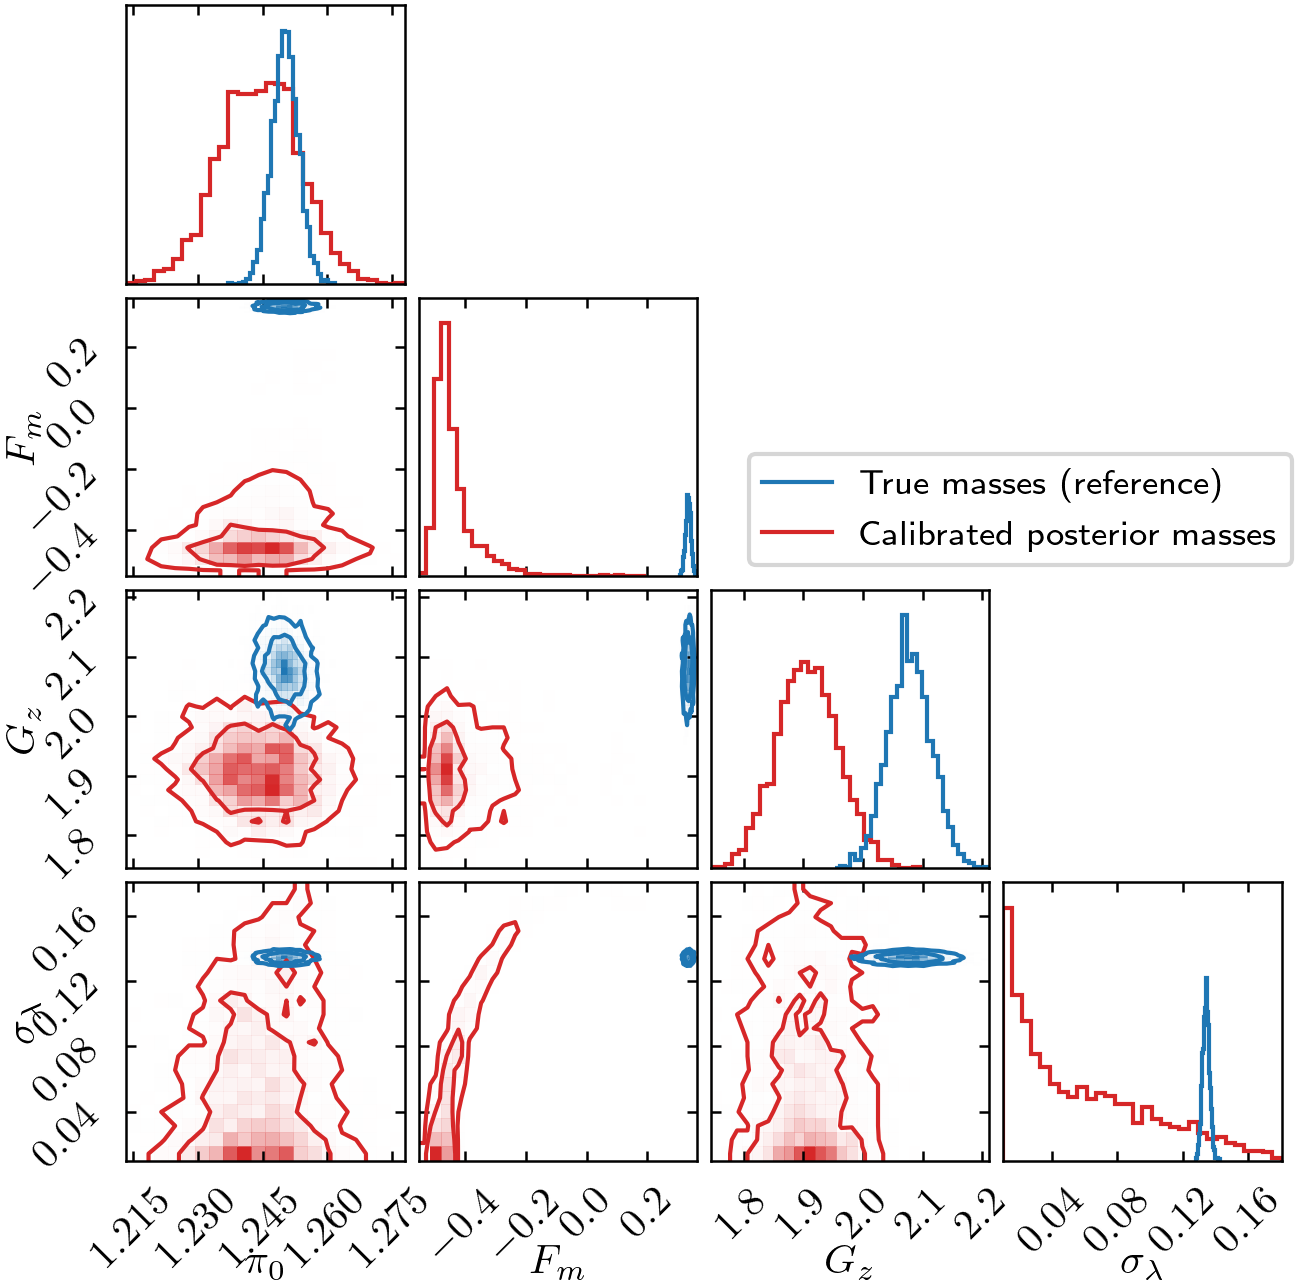

In [23]:
# Relation-parameter corner: calibrated (C3) vs true-mass reference (C0)
fig = plt.figure(figsize=(4.5, 4.5))
labels = [r"$\pi_0$", r"$F_m$", r"$G_z$", r"$\sigma_\lambda$"]
keys = ['pi0', 'Fm', 'Gz', 'sigl']

corner.corner(np.vstack([samples[k] for k in keys]).T, labels=labels,
              levels=[0.68, 0.95], fig=fig, color='C3', hist_bin_factor=1.5,
              plot_datapoints=False, no_fill_contours=True)
corner.corner(np.vstack([truesamples[k] for k in keys]).T, labels=labels,
              levels=[0.68, 0.95], fig=fig, color='C0', hist_bin_factor=1.5,
              plot_datapoints=False, no_fill_contours=True)
plt.plot([], [], color='C0', label='True masses (reference)')
plt.plot([], [], color='C3', label='Calibrated posterior masses')
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 2.6), fontsize='small')

Text(0.5, 0.98, 'Calibration parameters (black = OLS on cal subset)')

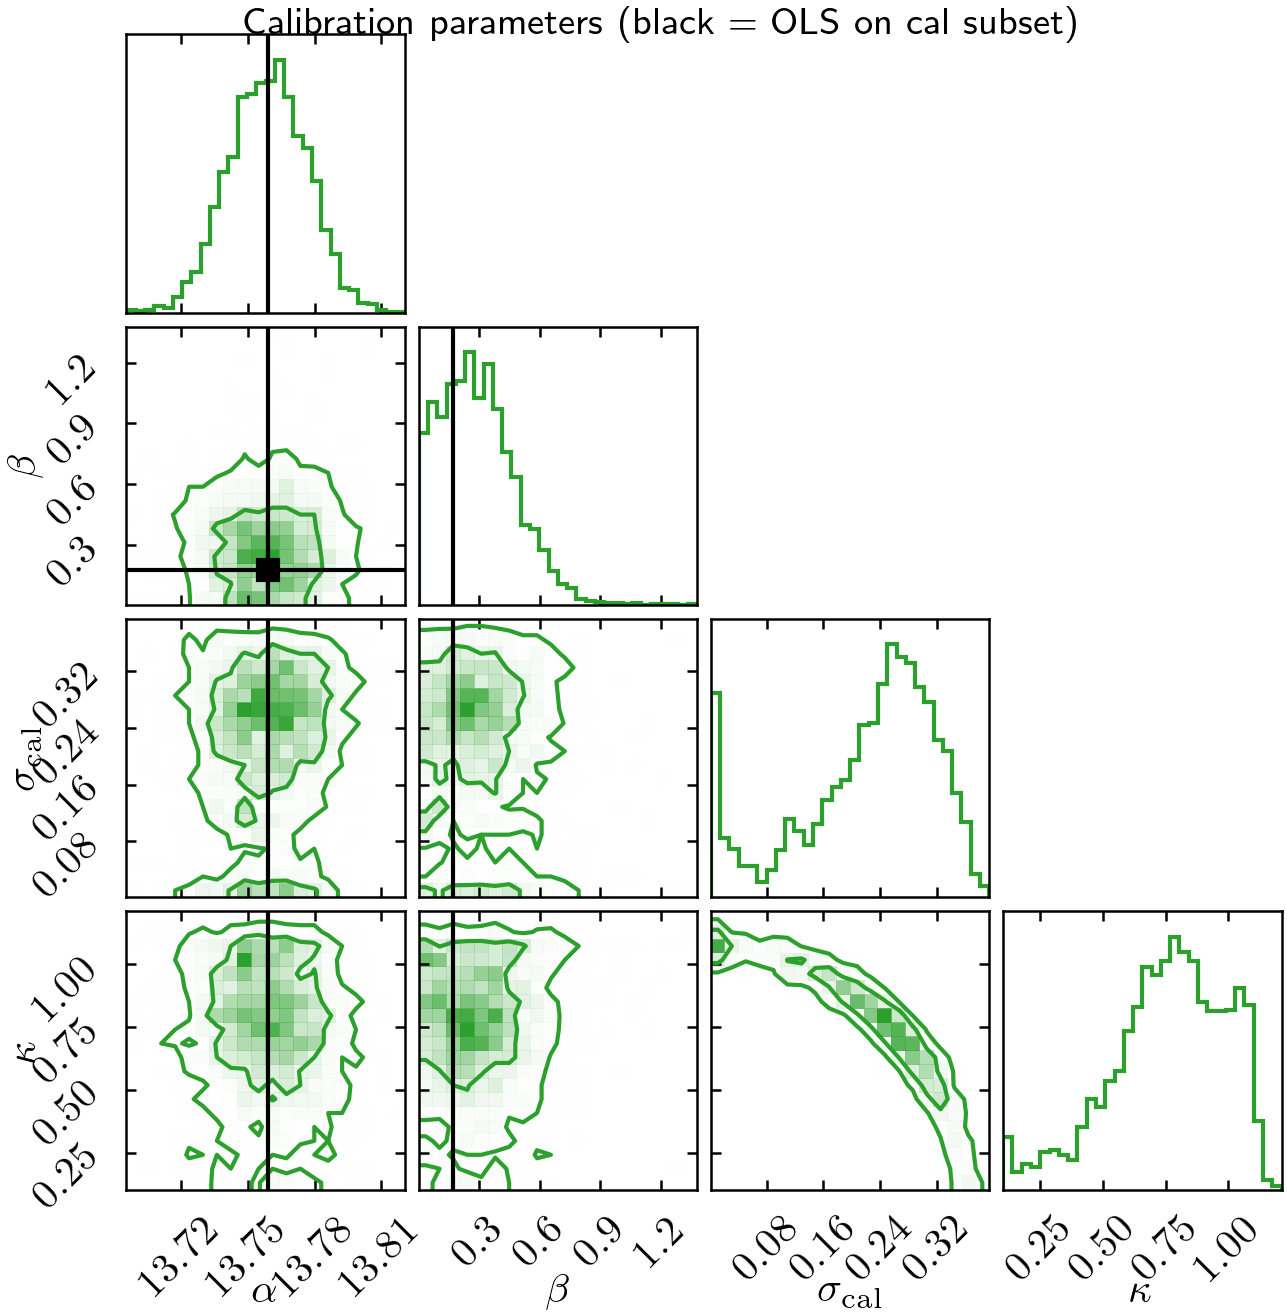

In [24]:
# Calibration-parameter corner, with OLS estimate (black) overlaid.
# Ideal: beta=1, kappa=1, sigcal small; alpha = mean true mass at mu_ref.
fig = plt.figure(figsize=(4.5, 4.5))
labels = [r"$\alpha$", r"$\beta$", r"$\sigma_{\rm cal}$", r"$\kappa$"]
keys = ['alpha', 'beta', 'sigcal', 'kappa']
truths = [ols_alpha, ols_beta, None, None]
corner.corner(np.vstack([samples[k] for k in keys]).T, labels=labels,
              levels=[0.68, 0.95], color='C2', hist_bin_factor=1.5,
              truths=truths, truth_color='k', fig=fig,
              plot_datapoints=False, no_fill_contours=True)
plt.suptitle('Calibration parameters (black = OLS on cal subset)', fontsize=9)

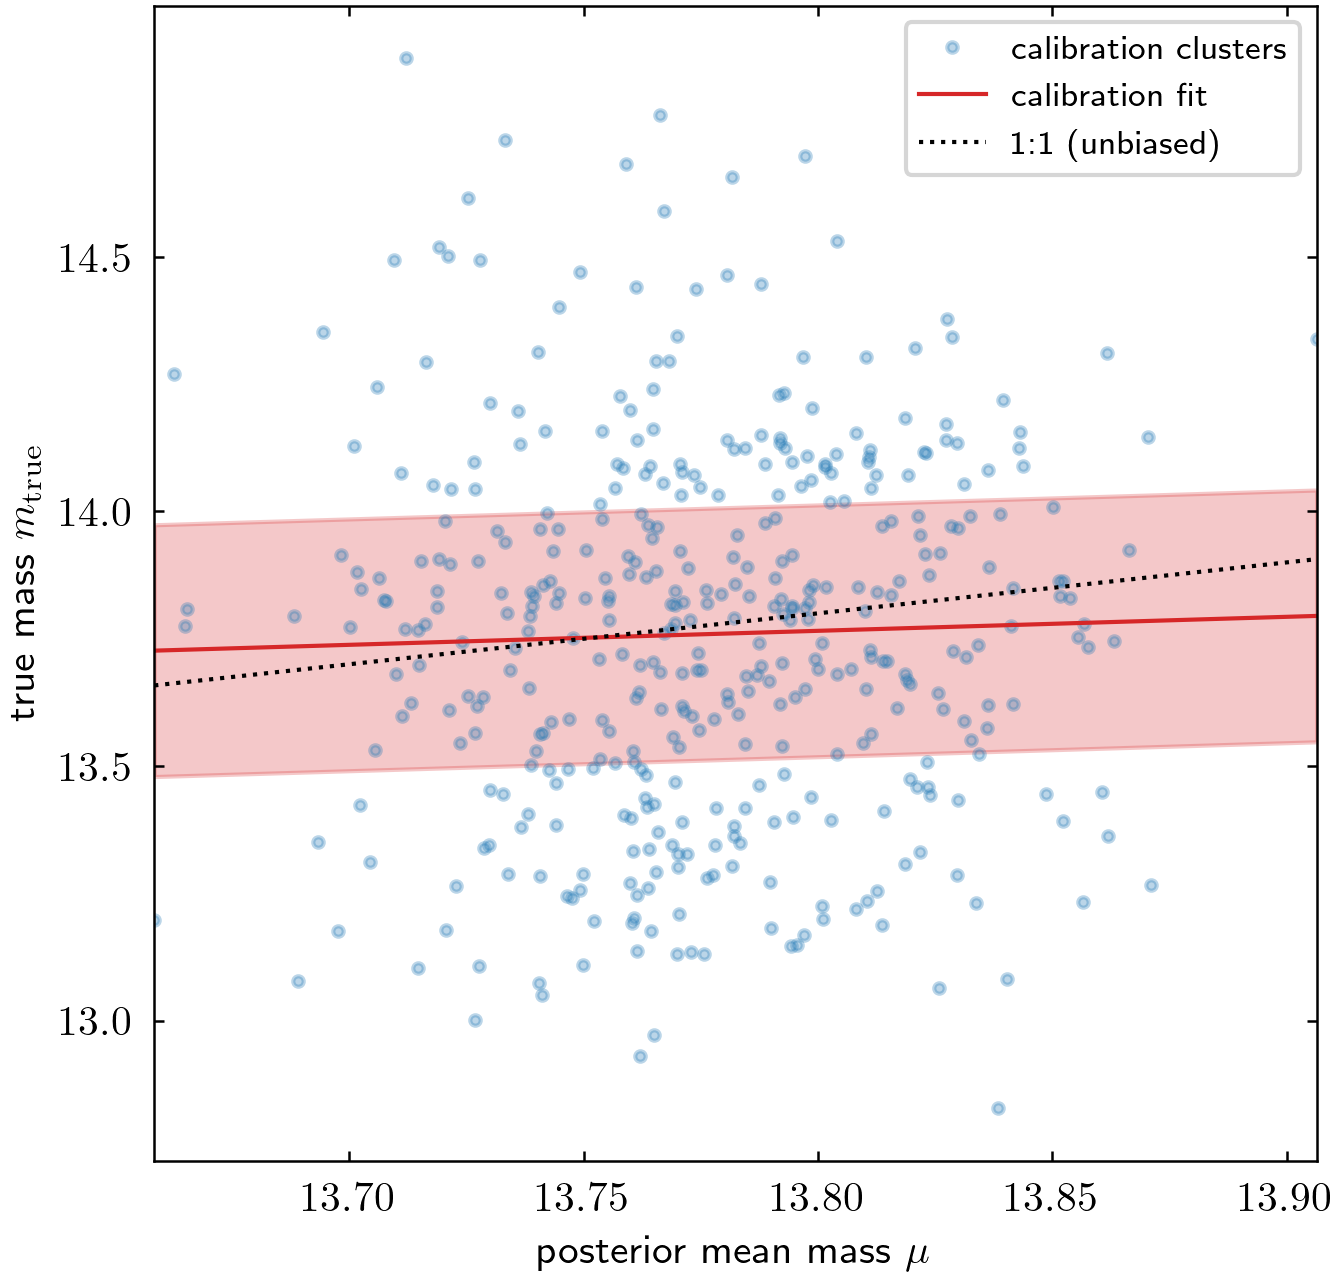

In [25]:
# Calibration check: true mass vs posterior mean for the cal subset
f, ax = plt.subplots(figsize=(5, 5))
ax.plot(mu_cal, mtrue_cal, '.', alpha=0.3, color='C0',
        label='calibration clusters')
xg = np.linspace(mu_cal.min(), mu_cal.max(), 100)
a_, b_ = np.median(samples['alpha']), np.median(samples['beta'])
sc_ = np.median(samples['sigcal'])
ax.plot(xg, a_ + b_*(xg - mu_ref), 'C3-', label='calibration fit')
ax.fill_between(xg, a_ + b_*(xg-mu_ref) - sc_, a_ + b_*(xg-mu_ref) + sc_,
                color='C3', alpha=0.25)
ax.plot(xg, xg, 'k:', label='1:1 (unbiased)')
ax.set_xlabel(r'posterior mean mass $\mu$')
ax.set_ylabel(r'true mass $m_{\rm true}$')
ax.legend(fontsize=8)

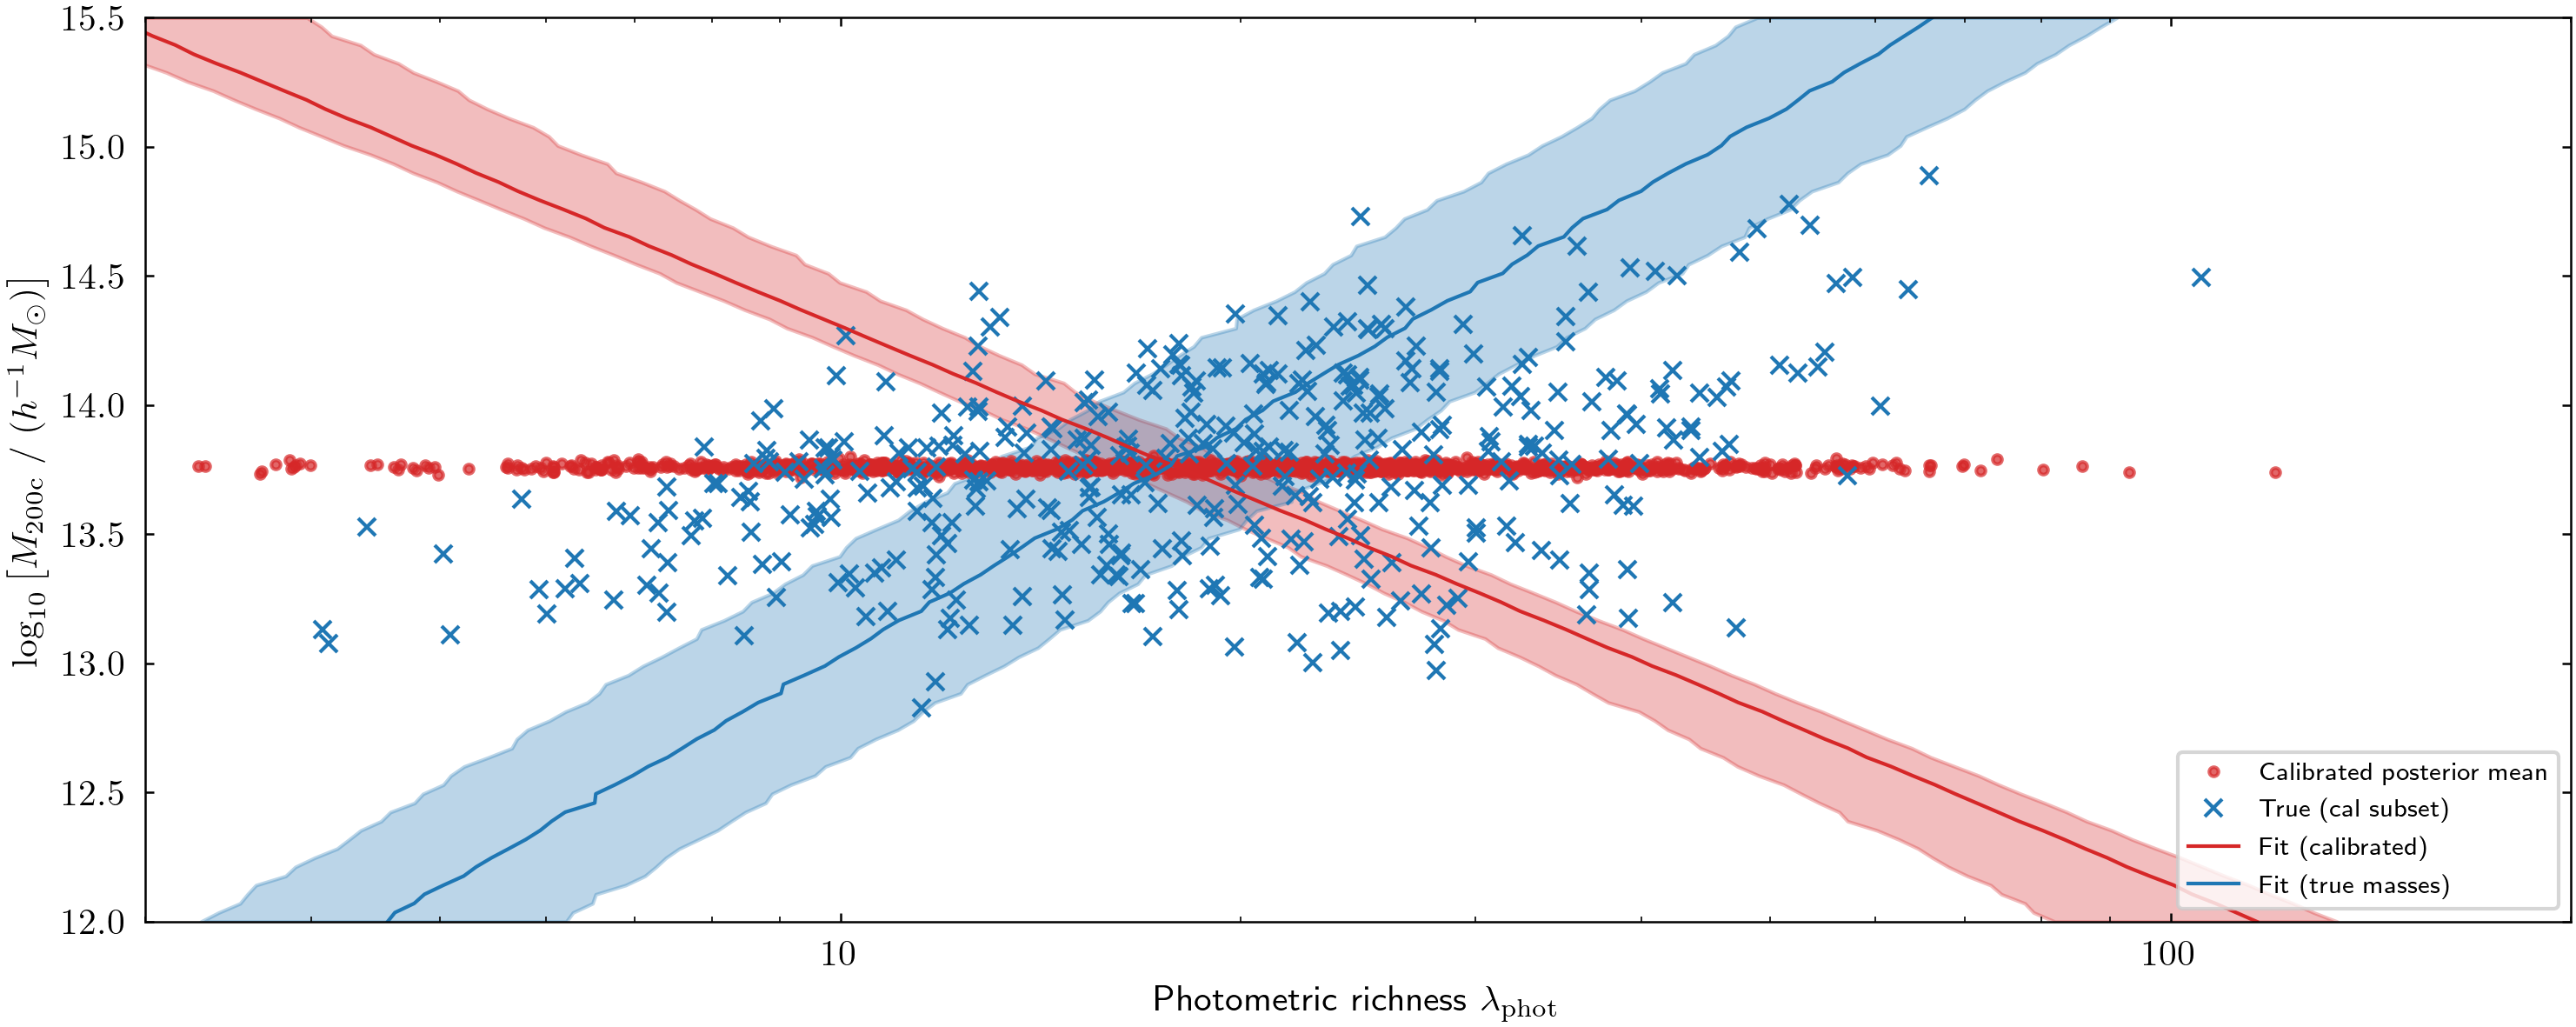

In [26]:
# Mass--richness fit: richness (x) vs M200c (y), using CALIBRATED main masses
f, ax = plt.subplots(1, 1, figsize=(12, 4.5))
ax.semilogx()

a_, b_ = np.median(samples['alpha']), np.median(samples['beta'])
mu_cal_main = a_ + b_*(mu_main - mu_ref)
rs_main = 10**loglam_main
ax.plot(rs_main, mu_cal_main, '.', color='C3', alpha=0.7,
        label='Calibrated posterior mean')
ax.plot(10**loglam_cal, mtrue_cal, 'x', color='C0', ms=5,
        label='True (cal subset)')

xm = np.linspace(12., 15.5, 100)   # mass grid (y-axis), at z = z0 (dz = 0)
for s, color, lab in [(samples, 'C3', 'Fit (calibrated)'),
                      (truesamples, 'C0', 'Fit (true masses)')]:
    lines = relation_mean(xm[:, None], 0.0, m0_piv, s['pi0'], s['Fm'], s['Gz'])
    lines = lines + s['sigl']*np.random.randn(*lines.shape)
    pr = np.percentile(10**lines, [16, 50, 84], axis=1)
    ax.plot(pr[1], xm, c=color, label=lab)
    ax.fill_betweenx(xm, pr[0], pr[2], alpha=0.3, color=color)

ax.set_xlim(3, 200)
ax.set_ylim(12., 15.5)
ax.set_xlabel(r'Photometric richness $\lambda_{\rm phot}$')
ax.set_ylabel(r'$\log_{10}\left[M_{\rm 200c}\ /\ (h^{-1}M_{\odot})\right]$')
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.legend(loc='lower right', fontsize=7)